<a href="https://www.kaggle.com/code/lalit7881/global-petrol-prices-april-2026?scriptVersionId=309283504" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices have increased.png
/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices.xlsx
/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Fuel price.pbix


In [2]:
import warnings
warnings.filterwarnings("ignore")

## Loading dataset

In [3]:
# Load dataset
df = pd.read_excel("/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices.xlsx")

# Basic info
print(df.head())
print(df.columns)
print(df.info())

       Country  Region  Price_Per_Liter_USD  Price_Per_Gallon_USD  \
0    Hong Kong    Asia                 4.11                 15.56   
1    Singapore    Asia                 3.38                 12.79   
2  Netherlands  Europe                 2.80                 10.60   
3      Denmark  Europe                 2.54                  9.61   
4      Germany  Europe                 2.47                  9.35   

   Previous_Price_USD  Price_Change_Percent     Price_Trend Price_Level  
0                3.78                   8.7          Stable   Very High  
1                2.84                  19.0  Rising Sharply   Very High  
2                2.56                   9.4          Stable   Very High  
3                2.26                  12.4          Rising   Very High  
4                2.18                  13.3          Rising   Very High  
Index(['Country', 'Region', 'Price_Per_Liter_USD', 'Price_Per_Gallon_USD',
       'Previous_Price_USD', 'Price_Change_Percent', 'Price_Trend'

In [4]:
df.tail()

,Country,Region,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent,Price_Trend,Price_Level
96,Russia,Europe/Asia,0.83,3.14,0.87,-4.6,Falling,Low
97,Turkey,Europe/Asia,1.44,5.45,1.18,22.0,Rising Sharply,Medium
98,Ukraine,Europe,1.52,5.75,1.39,9.4,Rising,Medium
99,Belarus,Europe,0.79,2.99,0.83,-4.8,Falling,Low
100,Syria,Middle East,0.74,2.80,2.15,-65.6,Falling Sharply,Low


In [5]:
df.describe()

,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent
count,101.000000,101.000000,101.000000,101.000000
mean,1.380891,5.227030,1.278911,8.030693
std,0.709434,2.685499,0.645317,14.363076
min,0.010000,0.040000,0.010000,-65.600000
25%,0.850000,3.220000,0.820000,0.000000
50%,1.310000,4.960000,1.200000,5.300000
75%,1.870000,7.080000,1.720000,12.700000
max,4.110000,15.560000,3.780000,55.100000


In [6]:
df.isnull().sum()

Country                 0
Region                  0
Price_Per_Liter_USD     0
Price_Per_Gallon_USD    0
Previous_Price_USD      0
Price_Change_Percent    0
Price_Trend             0
Price_Level             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

Country                  object
Region                   object
Price_Per_Liter_USD     float64
Price_Per_Gallon_USD    float64
Previous_Price_USD      float64
Price_Change_Percent    float64
Price_Trend              object
Price_Level              object
dtype: object

In [9]:
df.shape

(101, 8)

In [10]:
df.nunique()

Country                 101
Region                    8
Price_Per_Liter_USD      78
Price_Per_Gallon_USD     78
Previous_Price_USD       86
Price_Change_Percent     75
Price_Trend               6
Price_Level               5
dtype: int64

## EDA

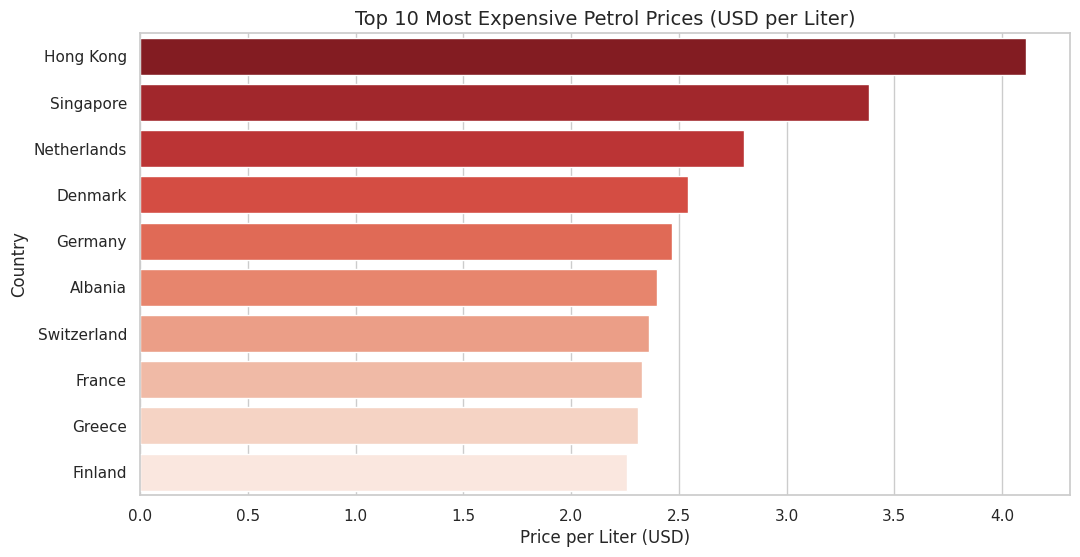

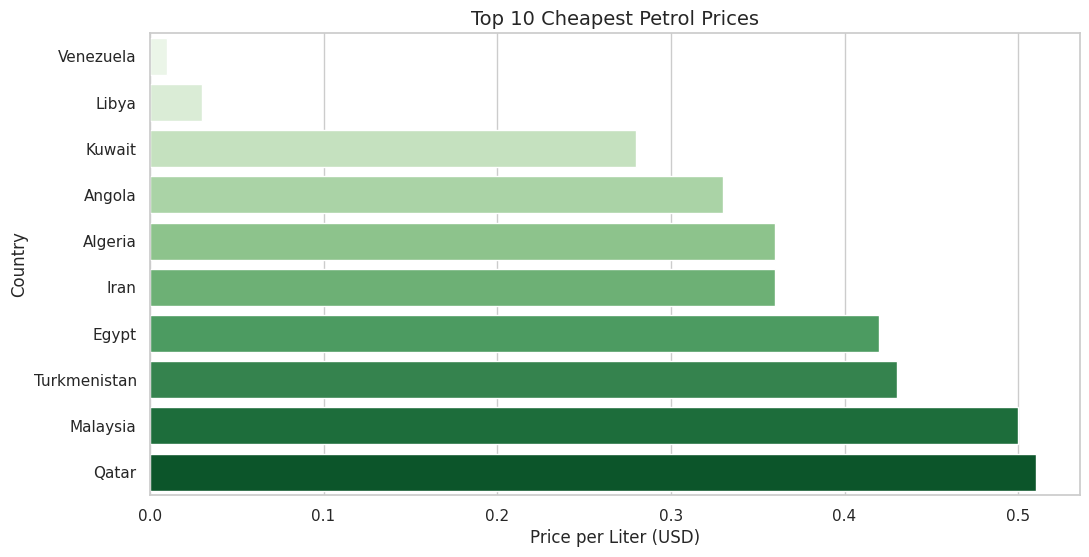

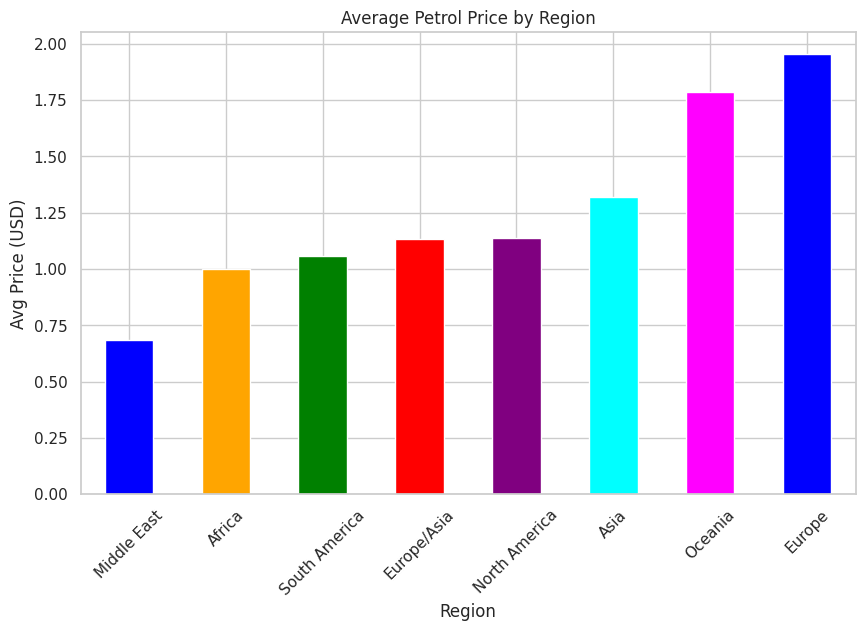

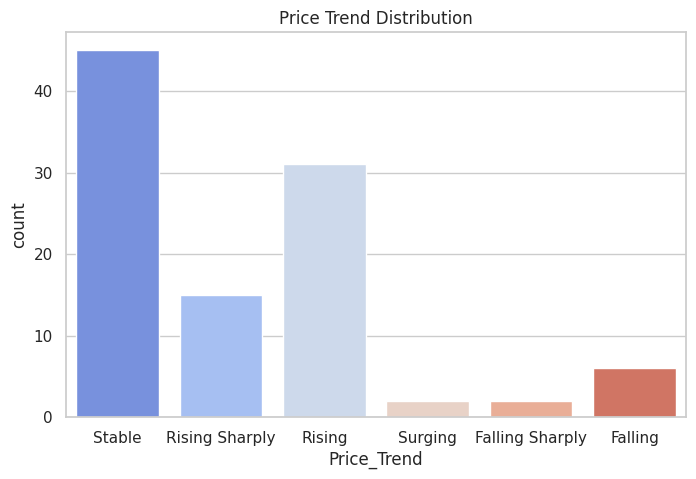

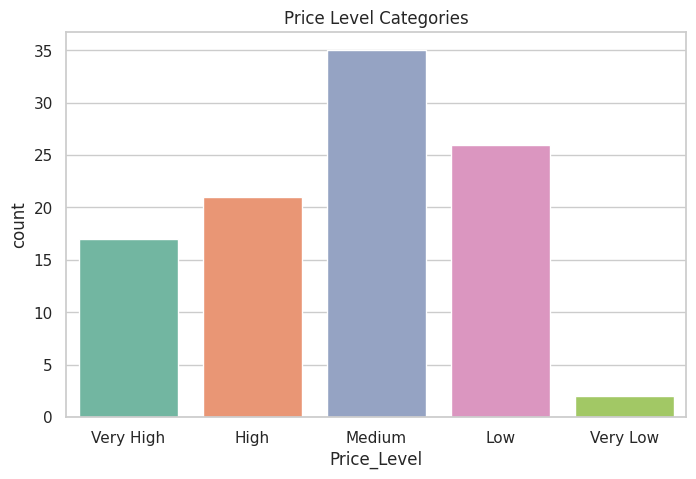

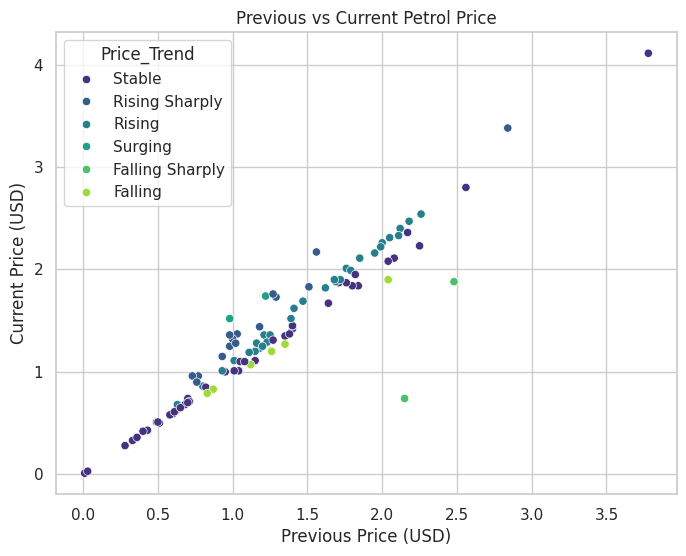

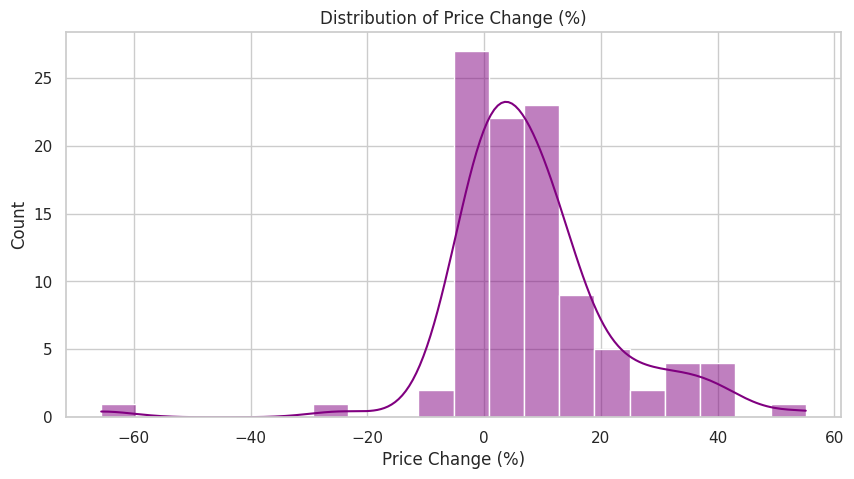

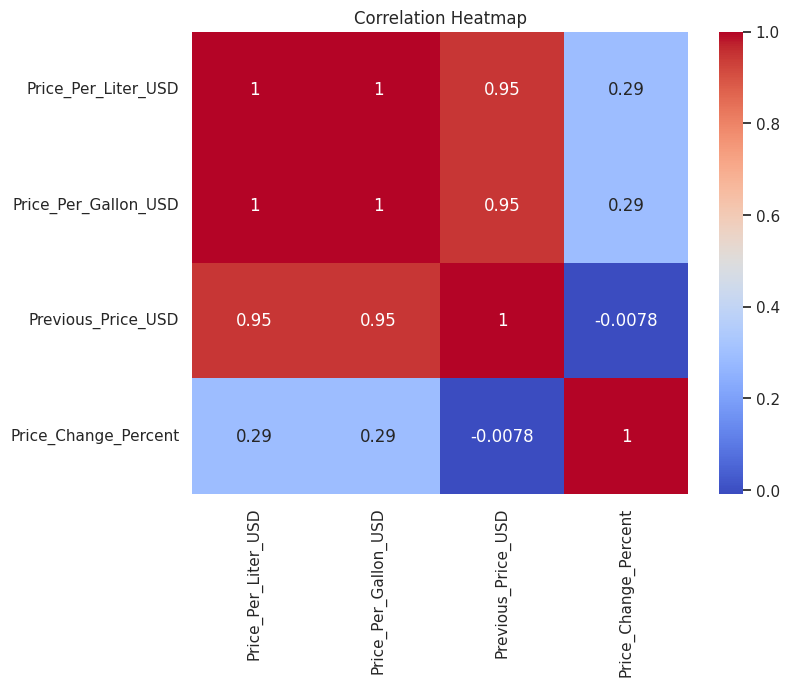

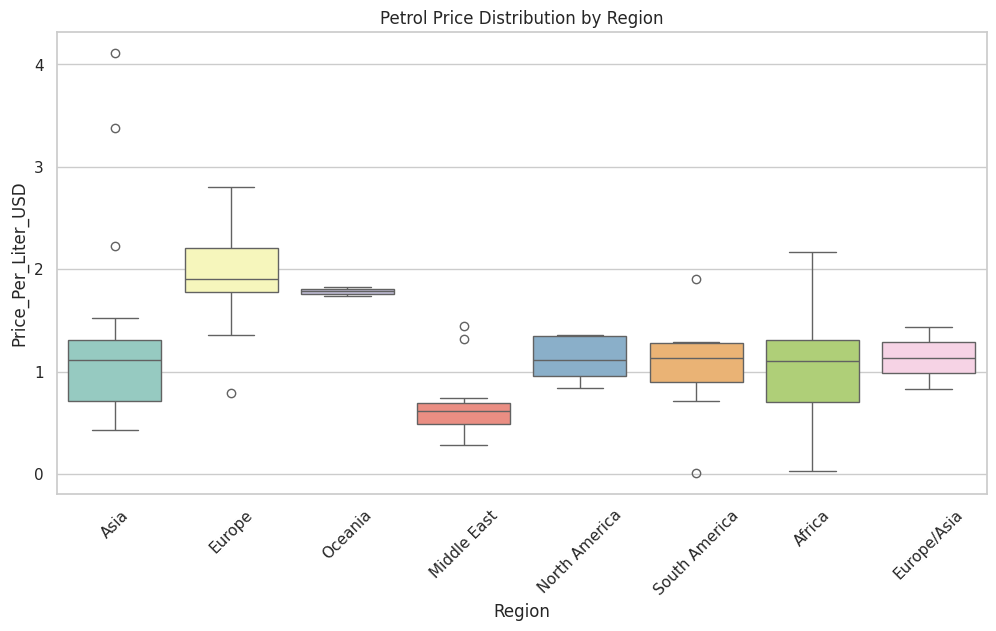

In [11]:

df.columns = df.columns.str.strip()

# Convert numeric columns safely
num_cols = [
    'Price_Per_Liter_USD',
    'Price_Per_Gallon_USD',
    'Previous_Price_USD',
    'Price_Change_Percent'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values (important for plotting)
df = df.dropna(subset=['Price_Per_Liter_USD', 'Previous_Price_USD'])

# Style
sns.set(style="whitegrid")

# ================================
# 1. Top 10 Most Expensive Countries
# ================================
top10 = df.sort_values(by='Price_Per_Liter_USD', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Price_Per_Liter_USD',
    y='Country',
    data=top10,
    palette='Reds_r'
)
plt.title("Top 10 Most Expensive Petrol Prices (USD per Liter)", fontsize=14)
plt.xlabel("Price per Liter (USD)")
plt.ylabel("Country")
plt.show()


# ================================
# 2. Top 10 Cheapest Countries
# ================================
cheap10 = df.sort_values(by='Price_Per_Liter_USD', ascending=True).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Price_Per_Liter_USD',
    y='Country',
    data=cheap10,
    palette='Greens'
)
plt.title("Top 10 Cheapest Petrol Prices", fontsize=14)
plt.xlabel("Price per Liter (USD)")
plt.ylabel("Country")
plt.show()


# ================================
# 3. Region-wise Average Price
# ================================
region_avg = df.groupby('Region')['Price_Per_Liter_USD'].mean().sort_values()

plt.figure(figsize=(10,6))
region_avg.plot(
    kind='bar',
    color=['blue','orange','green','red','purple','cyan','magenta']
)
plt.title("Average Petrol Price by Region")
plt.xlabel("Region")
plt.ylabel("Avg Price (USD)")
plt.xticks(rotation=45)
plt.show()


# ================================
# 4. Price Trend Count
# ================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Price_Trend',
    data=df,
    palette='coolwarm'
)
plt.title("Price Trend Distribution")
plt.show()


# ================================
# 5. Price Level Distribution
# ================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Price_Level',
    data=df,
    palette='Set2'
)
plt.title("Price Level Categories")
plt.show()


# ================================
# 6. Scatter Plot (FIXED)
# ================================
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,   # ✅ FIX ADDED
    x='Previous_Price_USD',
    y='Price_Per_Liter_USD',
    hue='Price_Trend',
    palette='viridis'
)
plt.title("Previous vs Current Petrol Price")
plt.xlabel("Previous Price (USD)")
plt.ylabel("Current Price (USD)")
plt.show()


# ================================
# 7. Price Change Distribution
# ================================
plt.figure(figsize=(10,5))
sns.histplot(
    df['Price_Change_Percent'].dropna(),
    bins=20,
    kde=True,
    color='purple'
)
plt.title("Distribution of Price Change (%)")
plt.xlabel("Price Change (%)")
plt.show()


# ================================
# 8. Heatmap (FIXED - you had wrong plot)
# ================================
plt.figure(figsize=(8,6))

corr = df[['Price_Per_Liter_USD',
           'Price_Per_Gallon_USD',
           'Previous_Price_USD',
           'Price_Change_Percent']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


# ================================
# 9. Boxplot (Price by Region)
# ================================
plt.figure(figsize=(12,6))
sns.boxplot(
    x='Region',
    y='Price_Per_Liter_USD',
    data=df,
    palette='Set3'
)
plt.xticks(rotation=45)
plt.title("Petrol Price Distribution by Region")
plt.show()

## Feture engineering

In [12]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



df.columns = df.columns.str.strip()

num_cols = [
    'Price_Per_Liter_USD',
    'Price_Per_Gallon_USD',
    'Previous_Price_USD',
    'Price_Change_Percent'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

# ================================
# 2. Features & Target
# ================================
target = 'Price_Level'

X = df.drop(columns=[target])
y = df[target]

# Encode target ONLY
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# ================================
# 3. Split (NO LEAKAGE)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 4. Preprocessing Pipeline
# ================================
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['number']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# ================================
# 5. Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# ================================
# 6. Train + Evaluate
# ================================
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    
    trained_models[name] = pipe


===== Logistic Regression =====
Accuracy: 0.9047619047619048
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.83      1.00      0.91         5
           2       0.88      1.00      0.93         7
           3       1.00      1.00      1.00         4
           4       0.00      0.00      0.00         1

    accuracy                           0.90        21
   macro avg       0.74      0.75      0.74        21
weighted avg       0.87      0.90      0.88        21


===== Decision Tree =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00     

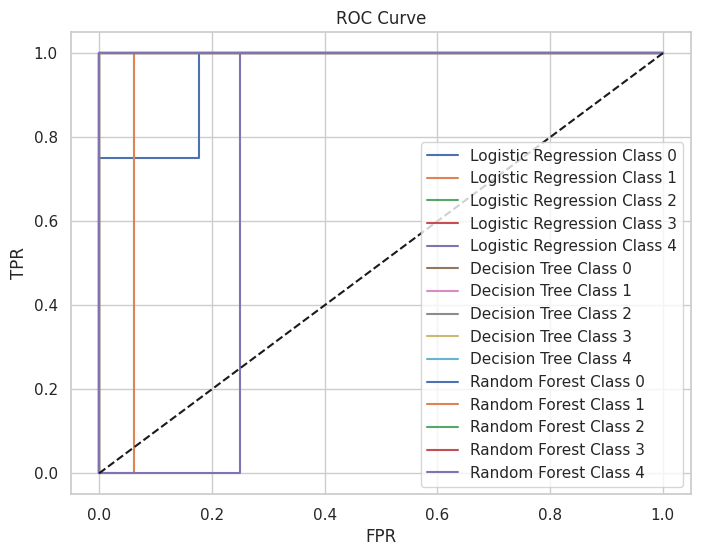

In [13]:
plt.figure(figsize=(8,6))

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

for name, model in trained_models.items():
    if hasattr(model.named_steps['model'], "predict_proba"):
        y_prob = model.predict_proba(X_test)
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f"{name} Class {i}")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!!!